# 第一晚被刀玩家统计（按水果代号）

从 `logs/session_*/game_complete.json` 与 `game_partial.json` 读取 `rounds[0].eliminated`（狼人刀的目标，**不论是否被医生救下**）。

在当前匿名设置中，`player_i` 会映射到一组固定水果代号（每局随机分配位置/角色）；这些名称仅为局内玩家代号，不代表真实身份。本 notebook 统计各代号被首夜刀的次数与频率。

In [ ]:
from __future__ import annotations

import json
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt


def project_root() -> Path:
    cwd = Path.cwd()
    if (cwd / "logs").is_dir():
        return cwd
    if (cwd.parent / "logs").is_dir():
        return cwd.parent
    return cwd


LOGS = project_root() / "logs"

try:
    from werewolf.config import ANONYMOUS_FIXED_NAMES  # type: ignore
    FIXED_NAMES = list(ANONYMOUS_FIXED_NAMES)
except Exception:
    # Fallback for environments where project import is unavailable
    FIXED_NAMES = [
        "Apple",
        "Avocado",
        "Orange",
        "Lemon",
        "Kiwi",
        "Mango",
        "Peach",
        "Plum",
    ]


def load_name_to_display(data: dict) -> dict[str, str]:
    """真实名 -> player_k，如 Bert -> player_0"""
    for key in ("seer", "doctor"):
        p = data.get(key) or {}
        m = p.get("name_to_display") or {}
        if m:
            return dict(m)
    for v in data.get("villagers") or []:
        m = v.get("name_to_display") or {}
        if m:
            return dict(m)
    for w in data.get("werewolves") or []:
        m = w.get("name_to_display") or {}
        if m:
            return dict(m)
    return {}


def target_to_alias_name(target_name: str, name_to_display: dict[str, str]) -> str | None:
    """把首夜目标统一映射为水果代号。"""
    if not target_name:
        return None

    t = str(target_name)

    # 目标本身已是水果代号
    if t in FIXED_NAMES:
        return t

    # 新日志：目标是 player_k，name_to_display 提供 player_k -> 水果代号
    if t in name_to_display:
        alias = str(name_to_display[t])
        return alias if alias in FIXED_NAMES else None

    # 旧日志：目标可能是旧真实名，name_to_display 为 真实名 -> player_k / 别名
    disp = name_to_display.get(t)
    if not disp:
        return None
    disp = str(disp)
    if disp in FIXED_NAMES:
        return disp

    # 兼容 player_k 形态
    m = re.search(r"player_(\d+)$", disp)
    if m:
        key = f"player_{int(m.group(1))}"
        alias = str(name_to_display.get(key, ""))
        return alias if alias in FIXED_NAMES else None
    return None


def first_night_kill_target(data: dict) -> str | None:
    rounds = data.get("rounds") or []
    if not rounds:
        return None
    return rounds[0].get("eliminated")


def iter_session_state_files(root: Path):
    """每个 session 目录只取一个状态文件：优先 game_complete.json。"""
    for d in sorted(root.glob("session_*")):
        if not d.is_dir():
            continue
        complete = d / "game_complete.json"
        partial = d / "game_partial.json"
        if complete.is_file():
            yield complete
        elif partial.is_file():
            yield partial


def collect_counts(logs_dir: Path) -> tuple[Counter[str], int, int]:
    """返回 (各水果代号计数, 总局数含刀目标, 无法映射的局数)"""
    counts: Counter[str] = Counter()
    total_with_target = 0
    unmapped = 0

    for path in iter_session_state_files(logs_dir):
        try:
            data = json.loads(path.read_text(encoding="utf-8"))
        except (OSError, json.JSONDecodeError):
            continue

        target = first_night_kill_target(data)
        if target is None:
            continue

        total_with_target += 1
        ntd = load_name_to_display(data)
        alias_name = target_to_alias_name(str(target), ntd)
        if alias_name is None:
            unmapped += 1
            continue
        counts[alias_name] += 1

    return counts, total_with_target, unmapped


In [140]:
counts, n_games, n_unmapped = collect_counts(LOGS)

# 固定 8 个水果代号，缺失为 0
values = [counts.get(name, 0) for name in FIXED_NAMES]
mapped = n_games - n_unmapped
probs = [v / mapped if mapped else 0.0 for v in values]

print(f"logs 目录: {LOGS.resolve()}")
print("当前水果代号:", FIXED_NAMES)
print(f"有第一晚刀目标的局数: {n_games}")
print(f"可映射到水果代号的局数: {mapped}")
print(f"无法映射（无 name_to_display 等）: {n_unmapped}")
print("各代号被刀次数:", dict(zip(FIXED_NAMES, values)))

logs 目录: D:\Github_Clone\werewolf_arena\logs
当前水果代号: ['Apple', 'Avocado', 'Pear', 'Lemon', 'Kiwi', 'Mango', 'Peach', 'Plum']
有第一晚刀目标的局数: 27
可映射到水果代号的局数: 27
无法映射（无 name_to_display 等）: 0
各代号被刀次数: {'Apple': 3, 'Avocado': 1, 'Pear': 0, 'Lemon': 3, 'Kiwi': 3, 'Mango': 8, 'Peach': 2, 'Plum': 7}


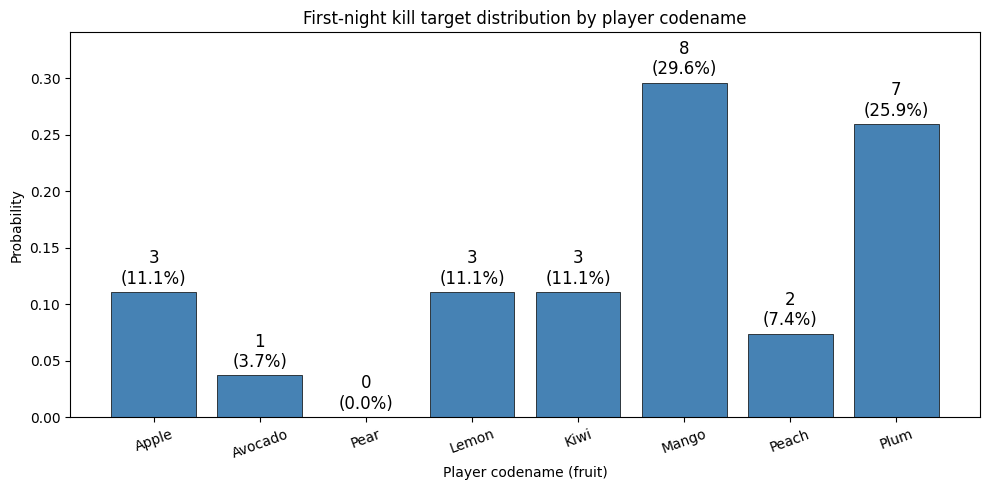

In [141]:
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(FIXED_NAMES))
bars = ax.bar(x, probs, color="steelblue", edgecolor="black", linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(FIXED_NAMES, rotation=20)
ax.set_ylabel("Probability")
ax.set_xlabel("Player codename (fruit)")
ax.set_title("First-night kill target distribution by player codename")
ax.set_ylim(0, max(probs) * 1.15 if max(probs) > 0 else 1.0)

for i, bar in enumerate(bars):
    h = bar.get_height()
    ax.annotate(
        f"{values[i]}\n({100 * probs[i]:.1f}%)",
        xy=(bar.get_x() + bar.get_width() / 2, h),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=12,
    )

plt.tight_layout()
plt.show()